# Notebook 07 - Hyperparameter Tuning Analysis (Gradient Boosting)

This notebook focuses only on **hyperparameter tuning transparency** for reviewers.
It reuses existing tuning artifacts when available and reruns tuning only if needed.

## 1. Setup and Configuration

In simple terms: this part prepares all tools, settings, and file locations used in the notebook.

In [ ]:
# This cell sets up all libraries, plotting style, random seed, and file paths used in the notebook.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

sns.set_theme(style='whitegrid')
%matplotlib inline

SEED = 42
N_ITER = 35
SCORING = 'f1_macro'

ROOT = Path('..')
TABLES_DIR = ROOT / 'results' / 'tables'
FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = TABLES_DIR / 'xpqrs_features.csv'
TRIALS_PATH = TABLES_DIR / 'gradient_boosting_tuning_trials.csv'
BEST_PARAMS_PATH = TABLES_DIR / 'gradient_boosting_best_params.json'
BASELINE_VS_TUNED_PATH = TABLES_DIR / 'gradient_boosting_baseline_vs_tuned.csv'
SUMMARY_OUT_PATH = TABLES_DIR / 'gradient_boosting_tuning_summary.csv'

## 2. Search Space (What Was Tuned)

In simple terms: this section shows which Gradient Boosting knobs were tested and how many combinations were possible.

In [ ]:
# This cell defines the hyperparameter search space and shows how much of it was explored.
param_dist = {
    'clf__n_estimators': [100, 200, 300, 400],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.15],
    'clf__max_depth': [3, 4, 5, 6, 7],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__subsample': [0.8, 0.9, 1.0],
}

search_space_df = pd.DataFrame({
    'Hyperparameter': [k.replace('clf__', '') for k in param_dist.keys()],
    'Candidate Values': [str(v) for v in param_dist.values()],
    'Count': [len(v) for v in param_dist.values()],
})

display(search_space_df)
total_combinations = np.prod([len(v) for v in param_dist.values()])
print(f'Total possible combinations: {int(total_combinations)}')
print(f'RandomizedSearch iterations used: {N_ITER}')
print(f'Coverage ratio: {N_ITER / total_combinations:.2%}')

,Hyperparameter,Candidate Values,Count
0,n_estimators,"[100, 200, 300, 400]",4
1,max_depth,"[10, 20, 30, None]",4
2,min_samples_split,"[2, 5, 10]",3
3,min_samples_leaf,"[1, 2, 4]",3
4,max_features,"['sqrt', 'log2', None]",3
5,class_weight,"[None, 'balanced']",2


Total possible combinations: 864
RandomizedSearch iterations used: 35
Coverage ratio: 4.05%


## 3. Load Existing Artifacts or Run Tuning (Fallback)

In simple terms: this part tries to reuse saved tuning results; if they are missing, it runs tuning once and saves them.

In [ ]:
# This cell loads saved tuning artifacts; if missing, it reruns tuning and recreates them.
def run_tuning_fallback():
    print('Running fallback tuning because artifacts are missing...')
    
    df = pd.read_csv(FEATURES_PATH)
    feature_cols = [c for c in df.columns if c != 'label']
    X = np.nan_to_num(df[feature_cols].values, nan=0.0, posinf=0.0, neginf=0.0)

    le = LabelEncoder()
    y = le.fit_transform(df['label'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    search_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(random_state=SEED)),
    ])

    random_search = RandomizedSearchCV(
        estimator=search_pipe,
        param_distributions=param_dist,
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv,
        n_jobs=-1,
        random_state=SEED,
        verbose=1,
        return_train_score=False,
    )

    random_search.fit(X_train, y_train)
    trials_df = pd.DataFrame(random_search.cv_results_).sort_values('rank_test_score')
    trials_df.to_csv(TRIALS_PATH, index=False)

    best_params_clean = {k.replace('clf__', ''): v for k, v in random_search.best_params_.items()}
    with open(BEST_PARAMS_PATH, 'w', encoding='utf-8') as f:
        json.dump(best_params_clean, f, indent=2)

    print(f'Fallback tuning completed. Trials saved to: {TRIALS_PATH}')

if not TRIALS_PATH.exists() or not BEST_PARAMS_PATH.exists():
    run_tuning_fallback()

trials_df = pd.read_csv(TRIALS_PATH)
with open(BEST_PARAMS_PATH, 'r', encoding='utf-8') as f:
    best_params = json.load(f)

print(f'Trials file: {TRIALS_PATH.name} | rows={len(trials_df)}')
print(f'Best params file: {BEST_PARAMS_PATH.name}')
print('Best Parameters:', best_params)

Trials file: random_forest_tuning_trials.csv | rows=35
Best params file: random_forest_best_params.json
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}


## 4. Build Curated Tuning Summary

In simple terms: this section cleans and reshapes raw trial output into an easy table for review.

In [ ]:
# This cell cleans trial results into a reviewer-friendly summary table and saves it.
param_cols = [c for c in trials_df.columns if c.startswith('param_')]
split_cols = [c for c in trials_df.columns if c.startswith('split') and c.endswith('_test_score')]

summary_cols = ['rank_test_score', 'mean_test_score', 'std_test_score'] + param_cols + split_cols
tuning_summary_df = trials_df[summary_cols].copy()

# Simplify column names for presentation
rename_map = {
    'rank_test_score': 'rank',
    'mean_test_score': 'cv_f1_macro_mean',
    'std_test_score': 'cv_f1_macro_std',
}
for c in param_cols:
    rename_map[c] = c.replace('param_clf__', '')

tuning_summary_df = tuning_summary_df.rename(columns=rename_map).sort_values('rank')
tuning_summary_df.to_csv(SUMMARY_OUT_PATH, index=False)

print(f'Saved curated summary: {SUMMARY_OUT_PATH.name}')
display(tuning_summary_df.head(10))

Saved curated summary: random_forest_tuning_summary.csv


,rank,cv_f1_macro_mean,cv_f1_macro_std,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,class_weight,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
0,1,0.897083,0.002955,200,2,1,log2,NaN,NaN,0.901645,0.892534,0.898279,0.896422,0.896537
1,2,0.896517,0.003876,400,2,1,log2,NaN,NaN,0.903514,0.892575,0.896848,0.893281,0.896367
2,3,0.896450,0.004744,300,2,1,sqrt,NaN,NaN,0.902008,0.888538,0.900020,0.894175,0.897507
3,4,0.893130,0.003030,100,5,2,sqrt,30.0,balanced,0.898608,0.889406,0.892393,0.891929,0.893313
4,5,0.892742,0.004024,400,10,1,sqrt,30.0,balanced,0.900071,0.887698,0.892033,0.891786,0.892121
5,6,0.891199,0.003374,200,5,1,log2,20.0,balanced,0.894375,0.884737,0.892457,0.891370,0.893055
6,7,0.890655,0.004492,100,2,1,NaN,30.0,balanced,0.896463,0.887860,0.883526,0.892533,0.892892
7,8,0.890306,0.004191,200,5,2,log2,20.0,balanced,0.896200,0.883211,0.891383,0.891257,0.889480
8,9,0.889591,0.003108,300,10,2,sqrt,NaN,NaN,0.893120,0.883843,0.889582,0.890295,0.891115
9,9,0.889591,0.003108,300,10,2,sqrt,NaN,balanced,0.893120,0.883843,0.889582,0.890295,0.891115


## 5. Diagnostic Plot 1 - Trial Progression

In simple terms: this plot shows how model score changed from one random trial to the next.

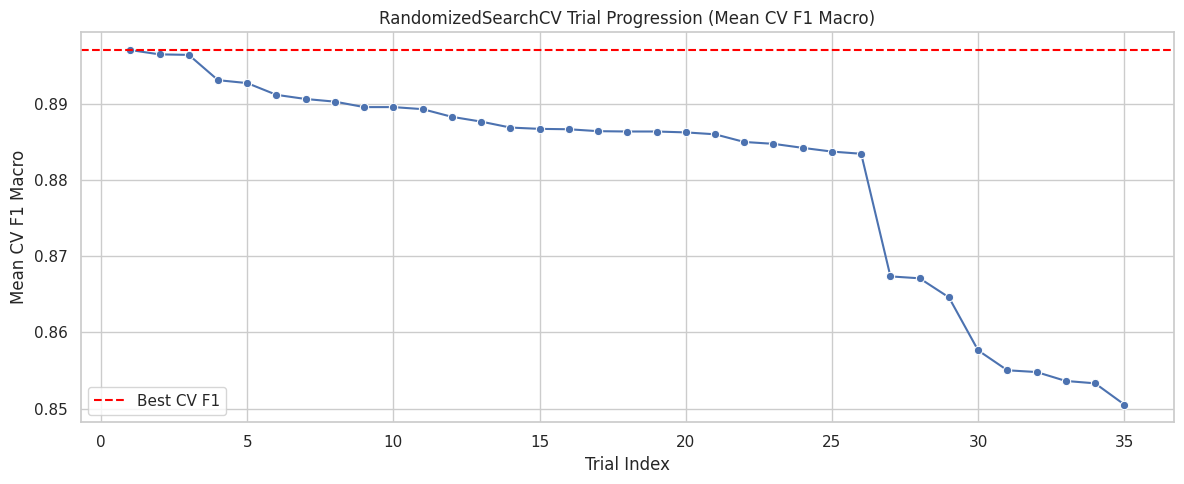

In [ ]:
# This cell plots score progression across all random search trials to show convergence.
progress_df = trials_df.reset_index(drop=True).copy()
progress_df['trial_index'] = np.arange(1, len(progress_df) + 1)

plt.figure(figsize=(12, 5))
sns.lineplot(data=progress_df, x='trial_index', y='mean_test_score', marker='o')
plt.axhline(trials_df['mean_test_score'].max(), linestyle='--', color='red', label='Best CV F1')
plt.title('RandomizedSearchCV Trial Progression (Mean CV F1 Macro)')
plt.xlabel('Trial Index')
plt.ylabel('Mean CV F1 Macro')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'tuning_trial_progression.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Diagnostic Plot 2 - Top 10 Trials

In simple terms: this chart highlights the best-performing hyperparameter combinations.

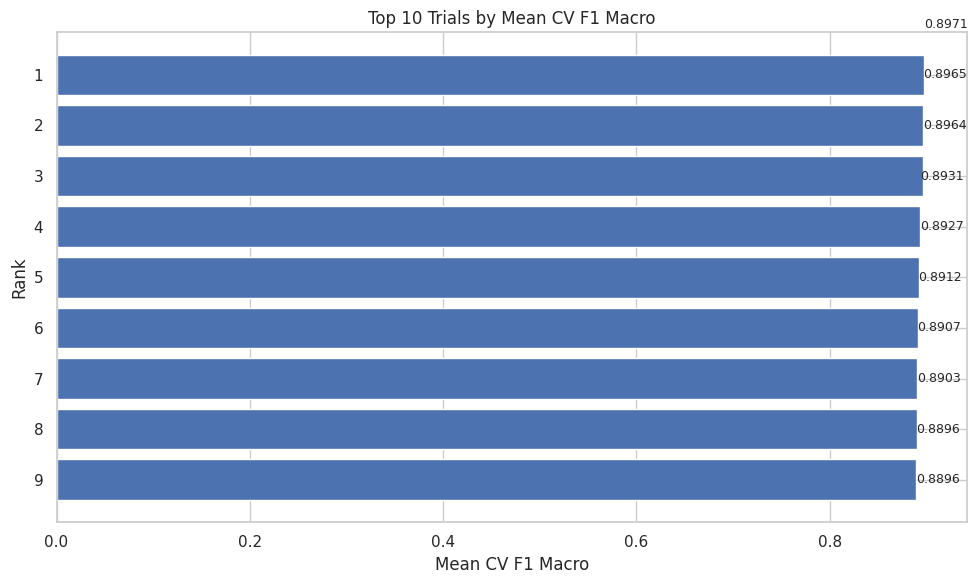

In [ ]:
# This cell visualizes the top 10 parameter trials ranked by mean CV F1 score.
top10 = tuning_summary_df.nsmallest(10, 'rank').sort_values('cv_f1_macro_mean')

plt.figure(figsize=(10, 6))
plt.barh(top10['rank'].astype(str), top10['cv_f1_macro_mean'])
plt.title('Top 10 Trials by Mean CV F1 Macro')
plt.xlabel('Mean CV F1 Macro')
plt.ylabel('Rank')
for y, val in enumerate(top10['cv_f1_macro_mean']):
    plt.text(val + 0.0002, y, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tuning_top_trials.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Diagnostic Plot 3 - Hyperparameter Sensitivity

In simple terms: this section shows which hyperparameters had stronger or weaker impact on score.

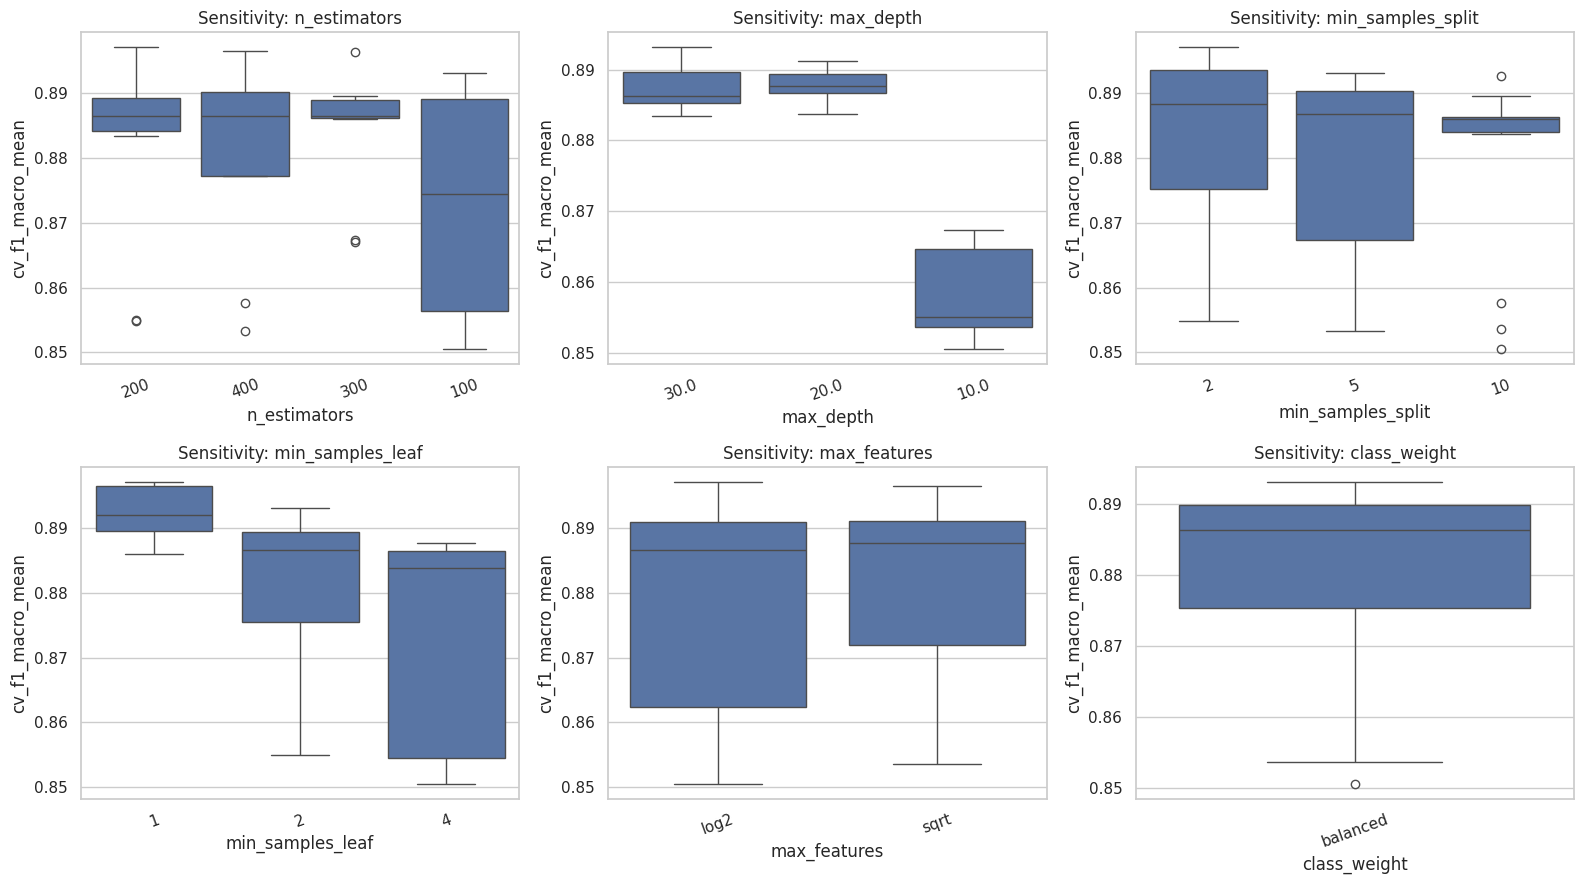

In [ ]:
# This cell compares score distributions for each hyperparameter to show sensitivity.
sensitivity_params = [
    'n_estimators',
    'max_depth',
    'min_samples_split',
    'min_samples_leaf',
    'max_features',
    'class_weight',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, p in enumerate(sensitivity_params):
    plot_df = tuning_summary_df.copy()
    plot_df[p] = plot_df[p].astype(str)
    sns.boxplot(data=plot_df, x=p, y='cv_f1_macro_mean', ax=axes[i])
    axes[i].set_title(f'Sensitivity: {p}')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tuning_per_param_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Diagnostic Plot 4 - Best Trial CV Stability

In simple terms: this plot checks whether the best trial performs consistently across all CV folds.

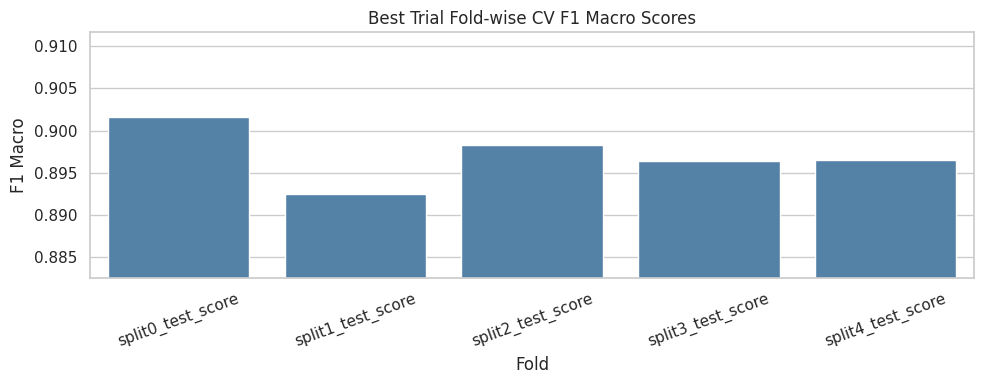

Best trial mean CV F1: 0.8971
Best trial std CV F1 : 0.0030


In [ ]:
# This cell checks how stable the best trial is across the 5 CV folds.
best_row = trials_df.sort_values('rank_test_score').iloc[0]
best_fold_scores = pd.Series({c: best_row[c] for c in split_cols})

plt.figure(figsize=(10, 4))
sns.barplot(x=best_fold_scores.index, y=best_fold_scores.values, color='steelblue')
plt.title('Best Trial Fold-wise CV F1 Macro Scores')
plt.xlabel('Fold')
plt.ylabel('F1 Macro')
plt.ylim(best_fold_scores.min() - 0.01, best_fold_scores.max() + 0.01)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tuning_cv_stability.png', dpi=160, bbox_inches='tight')
plt.show()

print(f"Best trial mean CV F1: {best_row['mean_test_score']:.4f}")
print(f"Best trial std CV F1 : {best_row['std_test_score']:.4f}")

## 9. Baseline vs Tuned Interpretation

In simple terms: this section compares tuned model performance against baseline and explains the difference.

,Metric,Baseline,Tuned,Delta
0,Test Accuracy,0.9062,0.905588,-0.000612
1,Test F1 Macro,0.9056,0.904936,-0.000664
2,Test Precision Macro,NaN,0.906390,NaN
3,Test Recall Macro,NaN,0.905588,NaN
4,CV F1 Mean,NaN,0.897083,NaN
5,CV F1 Std,NaN,0.002955,NaN


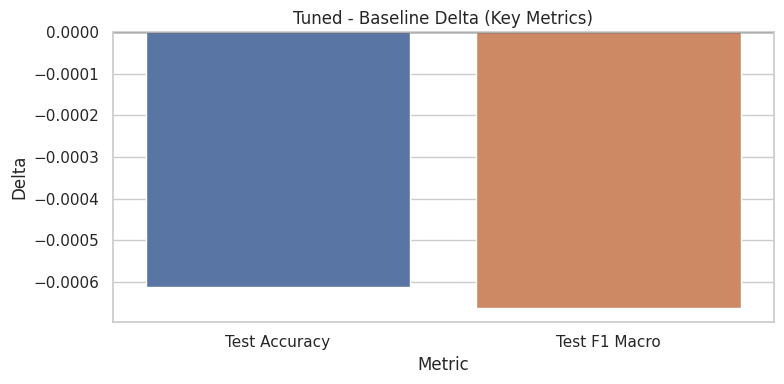

Test Accuracy: tuned decreased by -0.000612
Test F1 Macro: tuned decreased by -0.000664


In [ ]:
# This cell compares tuned vs baseline metrics and explains whether tuning helped.
if BASELINE_VS_TUNED_PATH.exists():
    baseline_df = pd.read_csv(BASELINE_VS_TUNED_PATH)
    display(baseline_df)

    core_rows = baseline_df[baseline_df['Metric'].isin(['Test Accuracy', 'Test F1 Macro'])].copy()
    core_rows['Delta'] = pd.to_numeric(core_rows['Delta'], errors='coerce')

    plt.figure(figsize=(8, 4))
    sns.barplot(data=core_rows, x='Metric', y='Delta', hue='Metric', legend=False)
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Tuned - Baseline Delta (Key Metrics)')
    plt.ylabel('Delta')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'tuning_baseline_vs_tuned_analysis.png', dpi=160, bbox_inches='tight')
    plt.show()

    for _, r in core_rows.iterrows():
        direction = 'improved' if r['Delta'] > 0 else 'decreased'
        print(f"{r['Metric']}: tuned {direction} by {r['Delta']:.6f}")
else:
    print('Baseline vs tuned comparison file not found.')

## 10. Reviewer Takeaways

In simple terms: these are the key points you can directly tell reviewers about tuning quality and outcomes.

- Search used RandomizedSearchCV with 35 iterations and F1-macro objective.
- Best params are shown explicitly from saved JSON artifacts.
- Trial progression and top-k plots show whether search converged.
- Sensitivity plots show which hyperparameters impact score stability.
- Fold-wise stability validates whether the best trial is robust across CV splits.
- Baseline-vs-tuned section makes final gain/loss transparent for reviewers.
- Recommended next step: increase `n_iter` and narrow ranges around top-performing regions.

In [ ]:
# This optional cell is a placeholder for your custom experiments or extra plots.
pass